In [1]:
import pandas as pd
import numpy as np
import torch
#plot the first dataframe
import matplotlib.pyplot as plt
import os

from pymatgen.core.structure import Structure, Lattice
from pymatgen.io.cif import CifParser
from io import StringIO
from collections import Counter
from tqdm import tqdm
import random

from scipy.interpolate import UnivariateSpline

def generate_structure(elements, stoichiometry):
    # Generate a random lattice
    a = b = c = random.uniform(3.0, 5.0)  # Random lattice parameters between 3 and 5 Å
    alpha = beta = gamma = 90  # Cubic lattice for simplicity
    lattice = Lattice.from_parameters(a, b, c, alpha, beta, gamma)

    # Create an empty structure
    structure = Structure(lattice, [], [])

    # Add atoms with random positions
    for element, stoich in zip(elements, stoichiometry):
        for _ in range(stoich):
            # Generate random fractional coordinates
            r_coords = [random.random() for _ in range(3)]
            structure.append(element, r_coords)

    return structure

def generate_cif_string_from_stoichiometry(elements_stoichiometry):
    # Parse elements and their stoichiometry
    elements, stoichiometry = [], []
    for item in elements_stoichiometry:
        element = ''.join(filter(str.isalpha, item))
        num = ''.join(filter(str.isdigit, item))
        stoich = int(num) if num.isdigit() else 1  # Default stoichiometry is 1 if not specified
        elements.append(element)
        stoichiometry.append(stoich)

    list_of_cifs = []

    #for every integer multiple of the stoichiometry that sums to less than 20
    for i in range(1, 20//sum(stoichiometry) + 1):
        # Generate structure
        structure = generate_structure(elements, [i * stoich for stoich in stoichiometry])

        # Generate CIF string
        cif_string = structure.to(fmt="cif")
        list_of_cifs.append(cif_string)

    return list_of_cifs

def get_atomic_numbers(cif_data): 
    cif_file_like_object = StringIO(cif_data)
    parser = CifParser(cif_file_like_object)
    structure = parser.get_structures()[0]
    return list(structure.atomic_numbers)

def get_formula(cif_data): 
    cif_file_like_object = StringIO(cif_data)
    parser = CifParser(cif_file_like_object)
    structure = parser.get_structures()[0]
    return structure.formula

class XRD_data():
    def __init__(self, data_dir, window_size = 100, s = 0.0001): 
        self.data_dir = data_dir
        self.pv_xrd_dict = self.get_xrds()
        self.window_size = window_size
        self.s = s
        self.interp_funcs = self.background_subtract_and_interpolate()

    def get_xrds(self): 
        pv_xrd_dictionary = {}
        for filename in os.listdir(self.data_dir):
            if filename.endswith('.csv'):
                csv = pd.read_csv(os.path.join(self.data_dir, filename), header = None, names = ['2theta', 'intensity'])
                pv_xrd_dictionary[filename] = csv

        return pv_xrd_dictionary

    def background_subtract_and_interpolate(self):
        interp_funcs = {}
        
        for key, pvxrd in tqdm(self.pv_xrd_dict.items()):
            # Convert data to DataFrame for rolling average calculation
            df = pd.DataFrame({'2theta': pvxrd['2theta'], 'intensity': pvxrd['intensity']})
            
            # Compute rolling average for background
            background = df['intensity'].rolling(window=self.window_size, min_periods=1, center=True).median()
            
            # Subtract background
            background_subtracted = df['intensity'] - background
            
            # Ensure no negative values after background subtraction
            background_subtracted[background_subtracted < 0] = 0
            
            # Interpolate using scipy
            interp_func = UnivariateSpline(df['2theta'], background_subtracted, s=self.s)

            interp_funcs[key] = interp_func
        
        return interp_funcs
    
    def change_domain(self): 
        for key, value in self.pv_xrd_dict.items():
            interp_xrd = self.interp_funcs[key]

            x_new = np.arange(5, 90, 0.01)
            y_new = interp_xrd(x_new) / max(interp_xrd(x_new))

            #zero out values outside the range of the original data
            y_new[x_new < min(value['2theta'])] = 0

            #make a new dataframe 
            new_df = pd.DataFrame({'2theta': x_new, 'intensity': y_new})

            self.pv_xrd_dict[key] = new_df

In [2]:
data_dir = '/home/gridsan/tmackey/cdvae/scripts/02-15-2024_clean_implementations_unsolved_compounds_PDF/xrds'

filenames = os.listdir(data_dir)
dictionary_of_cifs = {}
for index in range(len(filenames)):
    elements_stoichiometry = filenames[index].split('_')[1:-1]
    cif_string = generate_cif_string_from_stoichiometry(elements_stoichiometry)
    dictionary_of_cifs[filenames[index]] = cif_string

In [3]:
#initialize an empty dataframe with 'cif' and 'filename' columns
df = pd.DataFrame(columns = ['cif', 'filename'])

#for every key, item pair in the dictionary 
for key, item in dictionary_of_cifs.items():
    for individual_cif in item: 
        #concate the cif and filename to the dataframe
        df = pd.concat([df, pd.DataFrame({'cif': [individual_cif], 'filename': [key]})])
#add the formation_energy_per_atom and spacegroup.number columns and just set them to 0 
df['formation_energy_per_atom'] = 0
df['spacegroup.number'] = 0
#make a 'xrd_peak_intensities' and 'xrd_peak_locations' columns where each entry is 256 * [0]
df['xrd_peak_intensities'] = [256 * [0] for _ in range(len(df))]
df['xrd_peak_locations'] = [256 * [0] for _ in range(len(df))]
df['disc_sim_xrd'] = [np.array(256 * [0]) for _ in range(len(df))]

In [4]:
df['atomic_numbers'] = df['cif'].apply(get_atomic_numbers)
df['material_id'] = df['cif'].apply(get_formula)

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


In [5]:
my_XRD_directory = XRD_data(data_dir)

 18%|█▊        | 4/22 [00:36<02:44,  9.13s/it]


KeyboardInterrupt: 

In [16]:
minimums = [min(list(my_XRD_directory.pv_xrd_dict.values())[index]['2theta']) for index in range(len(my_XRD_directory.pv_xrd_dict))]
maximums = [max(list(my_XRD_directory.pv_xrd_dict.values())[index]['2theta']) for index in range(len(my_XRD_directory.pv_xrd_dict))]

(array([ 3.,  0.,  1.,  0., 10.,  0.,  0.,  1.,  1.,  1.,  0.,  1.,  1.,
         0.,  1.,  0.,  1.,  0.,  0.,  1.]),
 array([ 89.98 ,  92.481,  94.982,  97.483,  99.984, 102.485, 104.986,
        107.487, 109.988, 112.489, 114.99 , 117.491, 119.992, 122.493,
        124.994, 127.495, 129.996, 132.497, 134.998, 137.499, 140.   ]),
 <BarContainer object of 20 artists>)

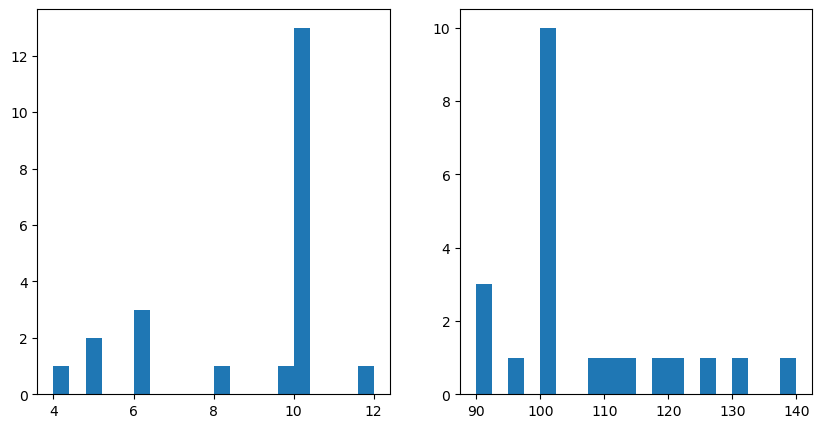

In [17]:
import matplotlib.pyplot as plt

#make a plot with 2 subplots
fig, axs = plt.subplots(1, 2, figsize = (10, 5))

#plot the minimums
axs[0].hist(minimums, bins = 20)

#plot the maximums
axs[1].hist(maximums, bins = 20)

In [8]:
my_XRD_directory.change_domain()

In [37]:
def create_xrd_for_testing(pv_xrd_dict, df):
    xrd_for_testing = {} 
    for row in range(df.shape[0]):
        filename = df.iloc[row]['filename']
        material_id = df.iloc[row]['material_id']
        tensor = torch.tensor(pv_xrd_dict[filename]['intensity'].values)
        normalized_tensor = tensor / torch.max(tensor)
        xrd_for_testing[material_id] = normalized_tensor.unsqueeze(0).float()
        
    return xrd_for_testing

In [38]:
pv_xrd_for_testing = create_xrd_for_testing(my_XRD_directory.pv_xrd_dict, df)

In [39]:
#save the df and pv_xrd_for_testing to csv and pt files respectively
test_dir = "/home/gridsan/tmackey/cdvae/data/PDF_unsolved_compounds"
df.to_csv(os.path.join(test_dir, 'test.csv'))
torch.save(pv_xrd_for_testing, os.path.join(test_dir, 'test_pv_xrd.pt'))

To double check: read the data back in

We now need to create graphs associated with this data. 

In [65]:
import numpy as np
import pandas as pd
import networkx as nx
import torch
import copy
import itertools

from pymatgen.core.structure import Structure
from pymatgen.core.lattice import Lattice
from pymatgen.analysis.graphs import StructureGraph
from pymatgen.analysis import local_env

from networkx.algorithms.components import is_connected

from sklearn.metrics import accuracy_score, recall_score, precision_score

from torch_scatter import scatter

from p_tqdm import p_umap

import ast
#import the random function library
import random

import os 

from tqdm.auto import tqdm
tqdm.pandas()

CrystalNN = local_env.CrystalNN(
    distance_cutoffs=None, x_diff_weight=-1, porous_adjustment=False)

from cdvae.common.data_utils import * 

import sys

#read in the worker number 
try: 
    worker_num = int(sys.argv[1])
except: 
    worker_num = 0

#read in the number of splits
try:
    num_splits = int(sys.argv[2])
except:
    num_splits = 1

def build_crystal(crystal_str, niggli=True, primitive=False):
    try: 
        """Build crystal from cif string."""
        crystal = Structure.from_str(crystal_str, fmt='cif')

        if primitive:
            crystal = crystal.get_primitive_structure()

        if niggli:
            crystal = crystal.get_reduced_structure()

        canonical_crystal = Structure(
            lattice=Lattice.from_parameters(*crystal.lattice.parameters),
            species=crystal.species,
            coords=crystal.frac_coords,
            coords_are_cartesian=False,
        )
        # match is gaurantteed because cif only uses lattice params & frac_coords
        # assert canonical_crystal.matches(crystal)
        return canonical_crystal
    except: 
        return None 

def build_crystal_graph(crystal, graph_method='crystalnn'):
    try: 
        """
        """

        if graph_method == 'crystalnn':
            crystal_graph = StructureGraph.with_local_env_strategy(
                crystal, CrystalNN)
        elif graph_method == 'none':
            pass
        else:
            raise NotImplementedError

        frac_coords = crystal.frac_coords
        atom_types = crystal.atomic_numbers
        lattice_parameters = crystal.lattice.parameters
        lengths = lattice_parameters[:3]
        angles = lattice_parameters[3:]

        assert np.allclose(crystal.lattice.matrix,
                        lattice_params_to_matrix(*lengths, *angles))

        edge_indices, to_jimages = [], []
        if graph_method != 'none':
            for i, j, to_jimage in crystal_graph.graph.edges(data='to_jimage'):
                edge_indices.append([j, i])
                to_jimages.append(to_jimage)
                edge_indices.append([i, j])
                to_jimages.append(tuple(-tj for tj in to_jimage))

        atom_types = np.array(atom_types)
        lengths, angles = np.array(lengths), np.array(angles)
        edge_indices = np.array(edge_indices)
        to_jimages = np.array(to_jimages)
        num_atoms = atom_types.shape[0]

        return frac_coords, atom_types, lengths, angles, edge_indices, to_jimages, num_atoms
    except: 
        return None
    
data_dir = '/home/gridsan/tmackey/cdvae/data/PDF_unsolved_compounds/'
#load in the data 
test_df = pd.read_csv(data_dir + 'test.csv')
data_frames = {'test': test_df}

for name, df in data_frames.items():
    
    chunk_size = np.ceil(len(df)/num_splits)
    
    start_index = int(worker_num*chunk_size)
    end_index = int(min(start_index + chunk_size, len(df))) #prevents end index > len(df)
    sub_df = df.iloc[start_index:end_index].copy()
    sub_crystals = sub_df['cif'].progress_apply(build_crystal)
    sub_graphs = sub_crystals.progress_apply(build_crystal_graph)

    materials_ids = sub_df['material_id'].values

    #make a dictionary using the materials_ids as keys and the graphs as values
    graph_dict = dict(zip(materials_ids, sub_graphs))

    #save the dictionary to a file
    torch.save(graph_dict, data_dir + '{}_{}.pt'.format(name, worker_num))
    
    print('Saved {}_{}.pt'.format(name, worker_num))

  0%|          | 0/48 [00:00<?, ?it/s]

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


  0%|          | 0/48 [00:00<?, ?it/s]

Saved test_0.pt


In [20]:
#load in the test.csv to double check 
test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/PDF_unsolved_compounds/" + 'test.csv')
old_test_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/unsolved_compounds/" + 'test.csv')

In [22]:
old_test_df

,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,disc_sim_xrd,counts_dict,length
0,37322,Ti3 Bi1,-0.072985,0.0000,Fe3Pt,0.043073,"['Fe', 'Pt']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,221,DiffractionPattern\n$2\Theta$: [23.72127081 33...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 83)",[ 0. 0. 0. 0. ...,"{26: 3, 78: 1}",4
1,25081,Ti6 Bi2,-0.032134,0.0000,Ag3Au,0.008414,"['Ag', 'Au']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,194,DiffractionPattern\n$2\Theta$: [17.38599516 25...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{47: 6, 79: 2}",8
2,22033,Ti9 Bi3,-0.309906,0.0000,NdNi3,0.003221,"['Nd', 'Ni']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,166,DiffractionPattern\n$2\Theta$: [10.69508605 20...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 83, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{60: 3, 28: 9}",12
3,21268,Ti12 Bi4,-0.292651,0.0000,Sn3Pd,0.001153,"['Sn', 'Pd']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,64,DiffractionPattern\n$2\Theta$: [10.12111317 19...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 2...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{50: 12, 46: 4}",16
4,22625,Ti15 Bi5,-0.431502,0.0000,TbAl3,0.004027,"['Al', 'Tb']",# generated using pymatgen\ndata_Ti3Bi\n_symme...,166,DiffractionPattern\n$2\Theta$: [ 7.36616783 14...,"[20.3863, 20.5348, 21.3687, 21.9075, 22.609, 2...","[1047.41, 758.96, 8911.19, 345.71, 9915.44, 71...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 2...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{65: 5, 13: 15}",20
5,17376,Ti3 Bi2,-0.766125,0.0000,Ba2Bi3,0.000000,"['Ba', 'Bi']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,71,DiffractionPattern\n$2\Theta$: [14.19813572 17...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{56: 2, 83: 3}",5
6,26518,Ti6 Bi4,-0.346087,0.0000,Tb3Ni2,0.010913,"['Ni', 'Tb']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,12,DiffractionPattern\n$2\Theta$: [ 9.67752882 13...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 22, 22, 22, 83, 83, 83, 83)",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{65: 6, 28: 4}",10
7,33872,Ti9 Bi6,-3.844539,3.4658,La2O3,0.029604,"['La', 'O']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,12,DiffractionPattern\n$2\Theta$: [ 9.74574958 12...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 83, 83, 8...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{57: 6, 8: 9}",15
8,27058,Ti12 Bi8,-2.354091,0.6267,Er2S3,0.012393,"['Er', 'S']",# generated using pymatgen\ndata_Ti3Bi2\n_symm...,62,DiffractionPattern\n$2\Theta$: [11.92649527 16...,"[20.7213, 21.639, 22.5394, 24.7526, 25.9839, 2...","[1151.22, 944.95, 1003.51, 1870.28, 945.42, 26...","(22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 2...",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,"{68: 8, 16: 12}",20
